Initial X-Block Rank: 4

--- TRANSFORMATION COMPLETE ---
Hadamards were forced on physical qubits: [4, 5, 6, 7]
Final Adjacency Matrix (Graph State):
 [[0 0 0 0 1 0 1 1]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 1 1 1 0]
 [0 0 0 0 1 1 0 1]
 [1 0 1 1 0 0 0 0]
 [0 1 1 1 0 0 0 0]
 [1 1 1 0 0 0 0 0]
 [1 1 0 1 0 0 0 0]]


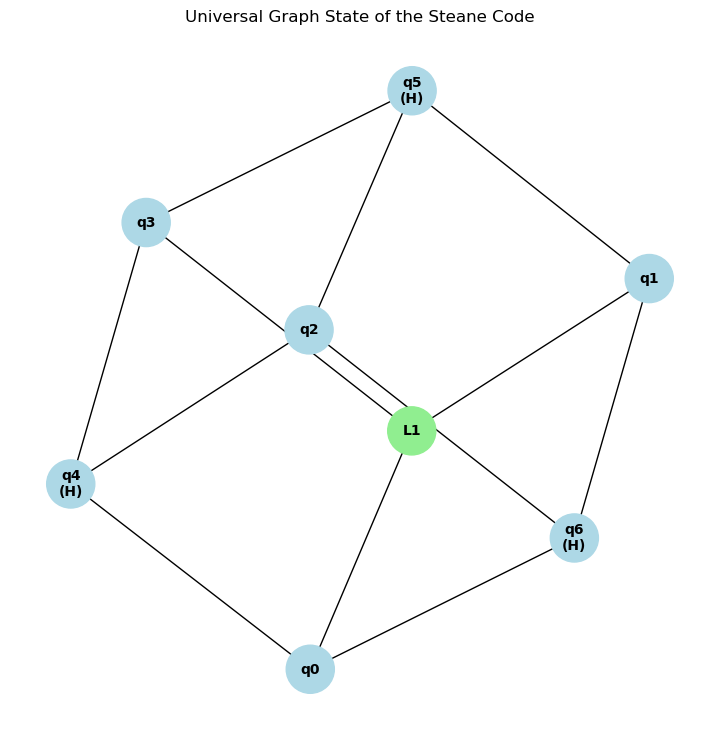

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def robust_tableau_to_graph(X_tab, Z_tab):
    """
    Rigorously converts a stabilizer tableau (X|Z) into a Graph State adjacency matrix (I|A).
    Applies local Hadamards (column swaps) when the X block is rank-deficient.
    """
    N = X_tab.shape[0]
    X = X_tab.copy()
    Z = Z_tab.copy()
    hadamards_applied = []

    for i in range(N):
        pivot_row = -1
        for j in range(i, N):
            if X[j, i] == 1:
                pivot_row = j
                break

        # If rank-deficient, apply local Hadamard to qubit i
        if pivot_row == -1:
            X[:, i], Z[:, i] = Z[:, i].copy(), X[:, i].copy()
            hadamards_applied.append(i)

            for j in range(i, N):
                if X[j, i] == 1:
                    pivot_row = j
                    break

        if pivot_row != i:
            X[[i, pivot_row]] = X[[pivot_row, i]]
            Z[[i, pivot_row]] = Z[[pivot_row, i]]

        for j in range(N):
            if i != j and X[j, i] == 1:
                X[j] = (X[j] + X[i]) % 2
                Z[j] = (Z[j] + Z[i]) % 2

    np.fill_diagonal(Z, 0)
    A = np.maximum(Z, Z.T)
    return A, hadamards_applied

# --- STEANE CODE [[7, 1, 3]] ---
n = 7  # Physical qubits
k = 1  # Logical qubit
N = n + k # Total nodes (8)

# Hamming(7,4) Parity Check Matrix
H_steane = np.array([
    [1, 0, 0, 1, 0, 1, 1],
    [0, 1, 0, 1, 1, 0, 1],
    [0, 0, 1, 0, 1, 1, 1]
])

Hx = H_steane
Hz = H_steane

# Logical Operators for Steane Code (Transversal X and Z)
Lx = np.array([[1, 1, 1, 1, 1, 1, 1]])
Lz = np.array([[1, 1, 1, 1, 1, 1, 1]])

# Build the (X|Z) tableau for the 8 joint generators
X_tab = np.zeros((N, N), dtype=int)
Z_tab = np.zeros((N, N), dtype=int)

# 3 X-Stabilizers
X_tab[0:3, :n] = Hx
# 3 Z-Stabilizers
Z_tab[3:6, :n] = Hz

# Logical X correlation
X_tab[6, :n] = Lx[0, :]
X_tab[6, n] = 1

# Logical Z correlation
Z_tab[7, :n] = Lz[0, :]
Z_tab[7, n] = 1

print("Initial X-Block Rank:", np.linalg.matrix_rank(X_tab % 2))

adj_matrix, hadamards_applied = robust_tableau_to_graph(X_tab, Z_tab)

print("\n--- TRANSFORMATION COMPLETE ---")
print(f"Hadamards were forced on physical qubits: {hadamards_applied}")
print("Final Adjacency Matrix (Graph State):\n", adj_matrix)

# Visualize
G = nx.from_numpy_array(adj_matrix)
plt.figure(figsize=(7, 7))

# Color coding: Nodes 0-6 are physical, Node 7 is logical
color_map = ['lightblue' if i < n else 'lightgreen' for i in range(N)]

# Add labels to clearly mark physical vs logical and highlight Hadamards
labels = {}
for i in range(N):
    if i == n:
        labels[i] = "L1"
    elif i in hadamards_applied:
        labels[i] = f"q{i}\n(H)"
    else:
        labels[i] = f"q{i}"

pos = nx.spring_layout(G, seed=10)
nx.draw(G, pos, labels=labels, node_color=color_map, node_size=1200, font_weight='bold', font_size=10)
plt.title("Universal Graph State of the Steane Code")
plt.show()

Generating Joint Tableau for Shor [[9,1,3]] Code...
X Tableau Shape: (22, 22)
Z Tableau Shape: (22, 22)
Initial X-Block Rank: 11

--- TRANSFORMATION COMPLETE ---
Hadamards were forced on physical qubits: [7, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Final Adjacency Matrix (Graph State):
 [[0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0]
 [1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 1 0]
 [1 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1]
 [1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 

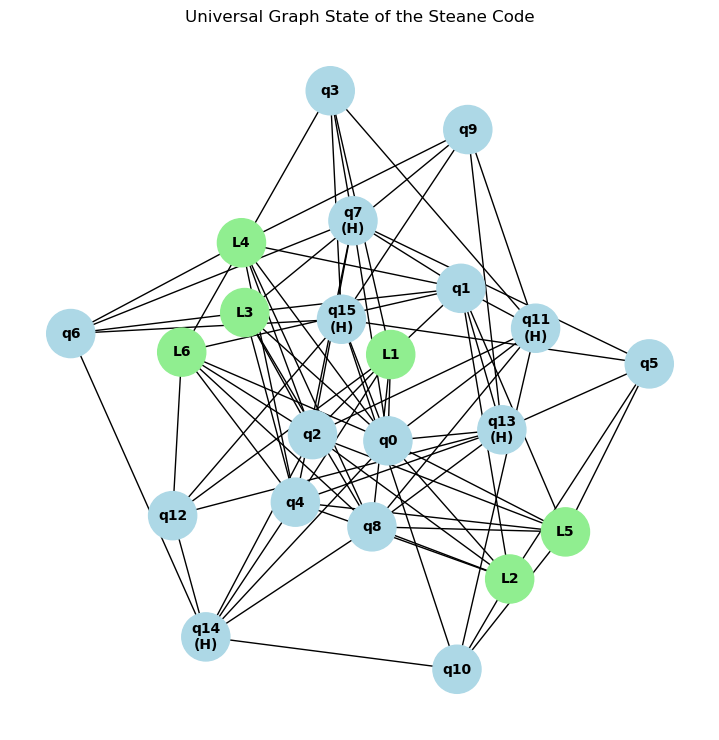

In [12]:
import numpy as np

def get_joint_tableau(Hx, Hz, Lx, Lz):
    """
    Constructs the (n+k) x (n+k) joint stabilizer tableau representing
    the universal graph state of a CSS code.

    Args:
        Hx, Hz: Parity check matrices for X and Z stabilizers.
        Lx, Lz: Logical X and Z operators (each row is a logical qubit).

    Returns:
        X_tab, Z_tab: The N x N matrices representing the joint state.
    """
    n = Hx.shape[1]
    k = Lx.shape[0]
    N = n + k

    # Verify dimensions (A valid CSS code should have exactly n-k independent stabilizers)
    num_stabilizers = Hx.shape[0] + Hz.shape[0]
    if num_stabilizers + 2*k != 2*N:
        # Note: We expect exactly N generators for an N-qubit state.
        # (n-k) stabilizers + 2k logicals = n + k = N.
        pass # We proceed, but row reduction later will catch dependencies

    X_tab = np.zeros((N, N), dtype=int)
    Z_tab = np.zeros((N, N), dtype=int)

    row = 0

    # 1. Add Physical X-Stabilizers: Sx ⊗ I
    for i in range(Hx.shape[0]):
        X_tab[row, :n] = Hx[i, :]
        row += 1

    # 2. Add Physical Z-Stabilizers: Sz ⊗ I
    for i in range(Hz.shape[0]):
        Z_tab[row, :n] = Hz[i, :]
        row += 1

    # 3. Add Logical X correlations: Lx ⊗ X_log
    for j in range(k):
        X_tab[row, :n] = Lx[j, :]
        X_tab[row, n+j] = 1  # X on the logical ancilla
        row += 1

    # 4. Add Logical Z correlations: Lz ⊗ Z_log
    for j in range(k):
        Z_tab[row, :n] = Lz[j, :]
        Z_tab[row, n+j] = 1  # Z on the logical ancilla
        row += 1

    return X_tab, Z_tab

# ==========================================
# TEST BENCH: CSS CODE LIBRARY
# ==========================================

# --- 1. The [[4, 2, 2]] Code (Small Toy Model) ---
# Useful for fast debugging. Encodes 2 logicals in 4 physicals.
H_422_x = np.array([[1, 1, 1, 1]])
H_422_z = np.array([[1, 1, 1, 1]])

L_422_x = np.array([
    [1, 1, 0, 0],
    [1, 0, 1, 0]
])
L_422_z = np.array([
    [1, 0, 1, 0],
    [1, 1, 0, 0]
])

# --- 2. The Shor [[9, 1, 3]] Code (Negative Control) ---
# A classic CSS code. Mathematically proven NOT to support transversal T.
# If your script finds a T gate symmetry here, the math is wrong!
H_shor_x = np.array([
    [1, 1, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 1]
])

H_shor_z = np.array([
    [1, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 1]
])

L_shor_x = np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1]])
L_shor_z = np.array([[1, 0, 0, 1, 0, 0, 1, 0, 0]])

# --- 3. The Steane [[7, 1, 3]] Code (Your Baseline) ---
H_steane_x = np.array([
    [1, 0, 0, 1, 0, 1, 1],
    [0, 1, 0, 1, 1, 0, 1],
    [0, 0, 1, 0, 1, 1, 1]
])
H_steane_z = H_steane_x
L_steane_x = np.array([[1, 1, 1, 1, 1, 1, 1]])
L_steane_z = np.array([[1, 1, 1, 1, 1, 1, 1]])

H_15_7_3_x = np.array([
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
])
H_15_7_3_z = H_15_7_3_x
L_15_7_3_x = np.array( [
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
])
L_15_7_3_z = L_15_7_3_x

H_serban_x = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
])

H_serban_z = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
])
L_serban_x = np.array([
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, ],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, ],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, ],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ],
])
L_serban_z = L_serban_x

# --- PLAYGROUND EXECUTION ---
print("Generating Joint Tableau for Shor [[9,1,3]] Code...")
X_serban, Z_serban = get_joint_tableau(H_serban_x, H_serban_z, L_serban_x, L_serban_z)
print("X Tableau Shape:", X_serban.shape)
print("Z Tableau Shape:", Z_serban.shape)

print("Initial X-Block Rank:", np.linalg.matrix_rank(X_serban % 2))

adj_matrix, hadamards_applied = robust_tableau_to_graph(X_serban, Z_serban)

print("\n--- TRANSFORMATION COMPLETE ---")
print(f"Hadamards were forced on physical qubits: {hadamards_applied}")
print("Final Adjacency Matrix (Graph State):\n", adj_matrix)

# Visualize
G = nx.from_numpy_array(adj_matrix)
plt.figure(figsize=(7, 7))

# Color coding: Nodes 0-6 are physical, Node 7 is logical
color_map = ['lightblue' if i <= 15 else 'lightgreen' for i in range(len(adj_matrix))]

# Add labels to clearly mark physical vs logical and highlight Hadamards
labels = {}
for i in range(len(adj_matrix)):
    if i > 15:
        labels[i] = f"L{i - 15}"
    elif i in hadamards_applied:
        labels[i] = f"q{i}\n(H)"
    else:
        labels[i] = f"q{i}"

pos = nx.spring_layout(G, seed=10)
nx.draw(G, pos, labels=labels, node_color=color_map, node_size=1200, font_weight='bold', font_size=10)
plt.title("Universal Graph State of the Steane Code")
plt.show()

In [14]:
import numpy as np
import networkx as nx
from itertools import combinations, product

# --- HELPER FUNCTIONS FOR THE SEARCH ---

def get_s_dot_lambda(G, K_nodes, S_array):
    """
    Calculates S • Lambda_G^K: The sum of the multiplicities in S
    for all vertices that are common neighbors of the set K.
    """
    if not K_nodes:
        return 0

    # Find common neighbors of all nodes in K
    common_neighbors = set(G.neighbors(K_nodes[0]))
    for node in K_nodes[1:]:
        common_neighbors.intersection_update(G.neighbors(node))

    # Sum the multiplicity (S_array) of those common neighbors
    return sum(S_array[v] for v in common_neighbors)

def is_valid_2_incident_multiset(G, S_array):
    """
    Checks if S_array (list of multiplicities) is a valid 2-incident
    independent multiset for Graph G.
    """
    # supp(S) are the nodes with multiplicity > 0
    supp_S = [i for i, mult in enumerate(S_array) if mult > 0]

    # 1. Independence Check (Fastest fail)
    for u, v in combinations(supp_S, 2):
        if G.has_edge(u, v):
            return False

    # V \ supp(S) contains the rest of the nodes (including the logical nodes!)
    V_minus_S = [i for i in G.nodes() if i not in supp_S]

    # 2. 2-Incidence Checks (r=2)
    # k=0: Pairs (size 2) in V \ supp(S). Must be mod 2^(2-0-1) = 2^1 = 2
    for pair in combinations(V_minus_S, 2):
        if get_s_dot_lambda(G, pair, S_array) % 2 != 0:
            return False

    # k=1: Triplets (size 3) in V \ supp(S). Must be mod 2^(2-1-0) = 2^1 = 2
    for triplet in combinations(V_minus_S, 3):
        if get_s_dot_lambda(G, triplet, S_array) % 2 != 0:
            return False

    return True

def search_lc2_symmetries(adj_matrix, num_physical_qubits):
    """
    Brute-force searches all possible multisets of physical qubits.
    """
    G = nx.from_numpy_array(adj_matrix)
    N = len(G.nodes())

    # We only iterate multisets over the physical qubits.
    # Logical qubits (indices >= num_physical_qubits) always have multiplicity 0 in S.
    possible_multiplicities = [0, 1, 2, 3] # Because r=2, multiplicity is mod 4

    print(f"Starting brute-force search over {4**num_physical_qubits} multisets...")
    valid_multisets = []

    # Generate all combinations of {0,1,2,3} for the physical qubits
    for physical_S in product(possible_multiplicities, repeat=num_physical_qubits):
        # Skip the empty set
        if sum(physical_S) == 0:
            continue

        # Pad with zeros for the logical qubits
        S_array = list(physical_S) + [0] * (N - num_physical_qubits)

        if is_valid_2_incident_multiset(G, S_array):
            valid_multisets.append(S_array)

    return valid_multisets

def apply_lc2_with_multiplicity(G, S_array):
    """
    Applies 2-local complementation strictly respecting the multiset multiplicities.
    S_array represents the multiplicity of each node in S (values 0, 1, 2, or 3).
    """
    G_new = G.copy()
    nodes = list(G.nodes())

    for u, v in combinations(nodes, 2):
        # 1. Find common neighbors of u and v
        common_neighbors = list(set(G.neighbors(u)).intersection(G.neighbors(v)))

        # 2. Sum the multiplicity of those common neighbors from the S_array
        # This accurately calculates S • Lambda_G^{u,v}
        s_dot_lambda = sum(S_array[w] for w in common_neighbors)

        # 3. Apply the Definition 9 toggle rule for r=2
        # Toggle if sum % (2^2) == 2^(2-1) -> sum % 4 == 2
        if s_dot_lambda % 4 == 2:
            if G_new.has_edge(u, v):
                G_new.remove_edge(u, v)
            else:
                G_new.add_edge(u, v)

    return G_new

def calculate_all_unitaries(G, S_array, hadamards_applied, num_physical_qubits, total_nodes):
    """
    Calculates unitaries for BOTH physical and logical nodes.
    Returns two dictionaries: physical_gates and logical_gates.
    """
    physical_gates = {}
    logical_gates = {}

    def format_phase(axis, multiplier):
        mult = multiplier % 8
        if mult == 0: return ""
        if mult == 4: return f"{axis}" # pi rotation

        fractions = {1: "π/4", 2: "π/2", 3: "3π/4", 5: "5π/4", 6: "3π/2", 7: "7π/4"}
        return f"{axis}({fractions[mult]})"

    for v in range(total_nodes):
        # 1. Base Multipliers
        x_mult = S_array[v] % 8
        z_sum = sum(S_array[w] for w in G.neighbors(v))
        z_mult = (-z_sum) % 8

        # 2. Hardware / Basis Correction
        if v in hadamards_applied:
            actual_x_mult = z_mult
            actual_z_mult = x_mult
        else:
            actual_x_mult = x_mult
            actual_z_mult = z_mult

        # 3. Format strings
        z_str = format_phase("Z", actual_z_mult)
        x_str = format_phase("X", actual_x_mult)
        gates = [g for g in [x_str, z_str] if g]
        gate_str = " * ".join(gates) if gates else "I"

        # 4. Route to correct dictionary
        if v < num_physical_qubits:
            physical_gates[f"q{v}"] = gate_str
        else:
            logical_gates[f"L{v - num_physical_qubits}"] = gate_str

    return physical_gates, logical_gates
# --- INTEGRATION WITH PREVIOUS SCRIPT ---
# Assuming 'adj_matrix' is the output from robust_tableau_to_graph from the previous turn
# For demonstration, I will create a dummy matrix here if you run it standalone,
# but you should pass the Steane code matrix into search_lc2_symmetries.

# WARNING: This is a placeholder graph just to make the script runnable.
# REPLACE 'adj_matrix' with the actual output from your Steane code script.
print("NOTE: Run the Steane code generation script first to get the true adj_matrix.")

results = search_lc2_symmetries(adj_matrix, num_physical_qubits=15)

print(f"\nSearch Complete. Found {len(results)} valid 2-incident multisets.")
S_arrays = []
for res in results:
    supp = [i for i, val in enumerate(res) if val > 0]
    print(f"Valid S array: {res} | Support nodes: {supp}")
    S_arrays.append(res)

num_phys = 15
total_nodes = 22

fig, axes = plt.subplots(nrows=len(S_arrays), ncols=1, figsize=(10, 6 * len(S_arrays)))
if len(S_arrays) == 1: axes = [axes]

for i, (ax, res) in enumerate(zip(axes, S_arrays), start=1):
    G_prime = apply_lc2_with_multiplicity(G, res)
    pos = nx.spring_layout(G_prime, seed=10)

    # Calculate separated unitaries
    phys_gates, log_gates = calculate_all_unitaries(G, res, hadamards_applied, num_phys, total_nodes)

    # Format text cleanly
    phys_text = " | ".join([f"{q}: {op}" for q, op in phys_gates.items() if op != "I"])
    log_text = " | ".join([f"{l}: {op}" for l, op in log_gates.items() if op != "I"])

    if not phys_text: phys_text = "Global Identity"
    if not log_text: log_text = "Identity (No Logical Effect)"

    nx.draw(G_prime, pos, ax=ax, labels=labels, node_color=color_map, node_size=1200, font_weight='bold', font_size=10)

    # Display both Physical and Logical unitaries clearly
    title_str = (f"Graph {i} | S = {res[:num_phys]}\n"
                 f"Physical Gates: {phys_text}\n"
                 f"EFFECTIVE LOGICAL: {log_text}")

    ax.set_title(title_str, pad=15)
    ax.axis("off")

plt.tight_layout()
plt.show()

NOTE: Run the Steane code generation script first to get the true adj_matrix.
Starting brute-force search over 1073741824 multisets...


KeyboardInterrupt: 